In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score 
from sklearn.metrics import classification_report,confusion_matrix
import warnings
import pickle
from scipy import stats
warnings.filterwarnings('ignore')


In [2]:
# Reading the file of csv 
df = pd.read_csv("insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [3]:
df.isna().any

<bound method DataFrame.any of      months_as_customer    age  policy_number  policy_bind_date  policy_state  \
0                 False  False          False             False         False   
1                 False  False          False             False         False   
2                 False  False          False             False         False   
3                 False  False          False             False         False   
4                 False  False          False             False         False   
..                  ...    ...            ...               ...           ...   
995               False  False          False             False         False   
996               False  False          False             False         False   
997               False  False          False             False         False   
998               False  False          False             False         False   
999               False  False          False             False         False 

In [4]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [5]:
import pandas as pd
df = pd.read_csv('insurance_claims.csv')   # or however you create it

In [6]:
IQR = []
IQR.append(df['age'].quantile(0.75) - df['age'].quantile(0.25))
IQR.append(df['policy_annual_premium'].quantile(0.75) - df['policy_annual_premium'].quantile(0.25))
IQR.append(df['umbrella_limit'].quantile(0.75) - df['umbrella_limit'].quantile(0.25))
IQR.append(df['total_claim_amount'].quantile(0.75) - df['total_claim_amount'].quantile(0.25))
IQR.append(df['property_claim'].quantile(0.75) - df['property_claim'].quantile(0.25))
IQR

[np.float64(12.0),
 np.float64(326.0875000000001),
 np.float64(0.0),
 np.float64(28780.0),
 np.float64(6440.0)]

In [7]:
upper = []
upper.append(df['age'].quantile(0.75) + 1.5 * IQR[0])
upper.append(df['policy_annual_premium'].quantile(0.75) + 1.5 * IQR[1])
upper.append(df['umbrella_limit'].quantile(0.75) + 1.5 * IQR[2])
upper.append(df['total_claim_amount'].quantile(0.75) + 1.5 * IQR[3])
upper.append(df['property_claim'].quantile(0.75) + 1.5 * IQR[4])
upper

[np.float64(62.0),
 np.float64(1904.8262500000003),
 np.float64(0.0),
 np.float64(113762.5),
 np.float64(20545.0)]

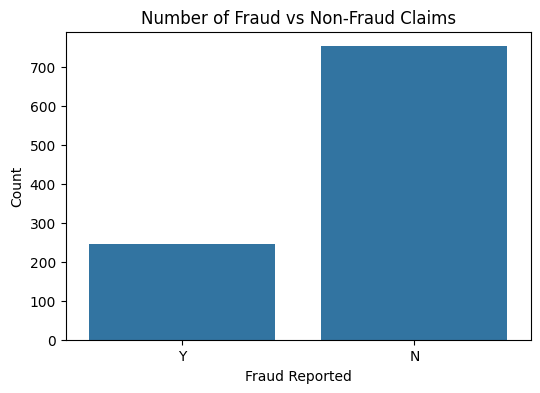

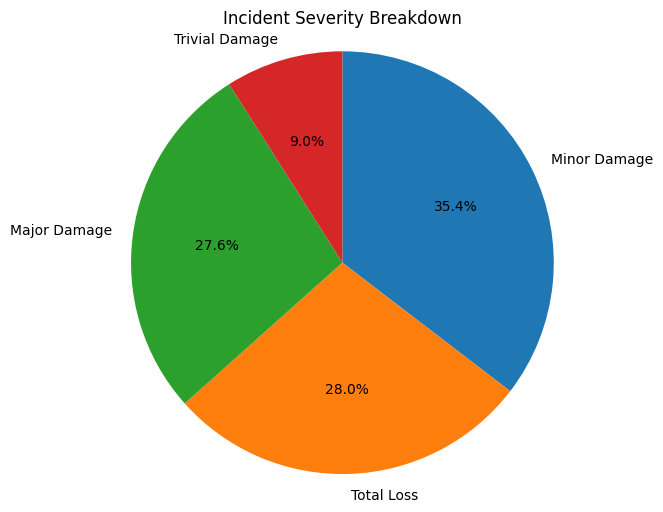

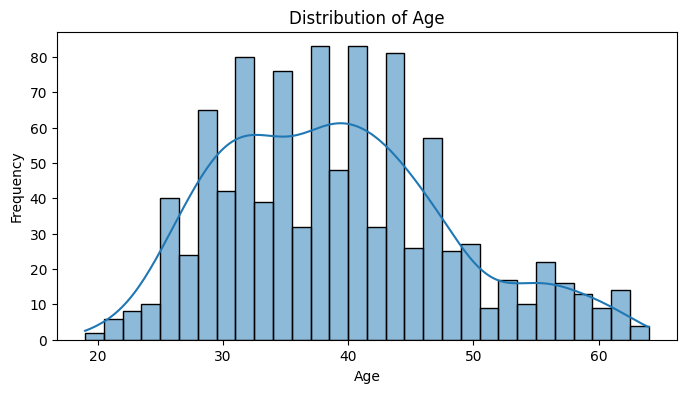

In [8]:
# univariate visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Countplot for fraud_reported (categorical feature)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='fraud_reported')
plt.title('Number of Fraud vs Non‑Fraud Claims')
plt.xlabel('Fraud Reported')
plt.ylabel('Count')
plt.show()

# 2. Pie chart for incident_severity composition
counts = df['incident_severity'].value_counts()
plt.figure(figsize=(6,6))
counts.plot.pie(autopct='%1.1f%%', startangle=90,
                counterclock=False, ylabel='')
plt.title('Incident Severity Breakdown')
plt.axis('equal')
plt.show()

# 3. Histogram for age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

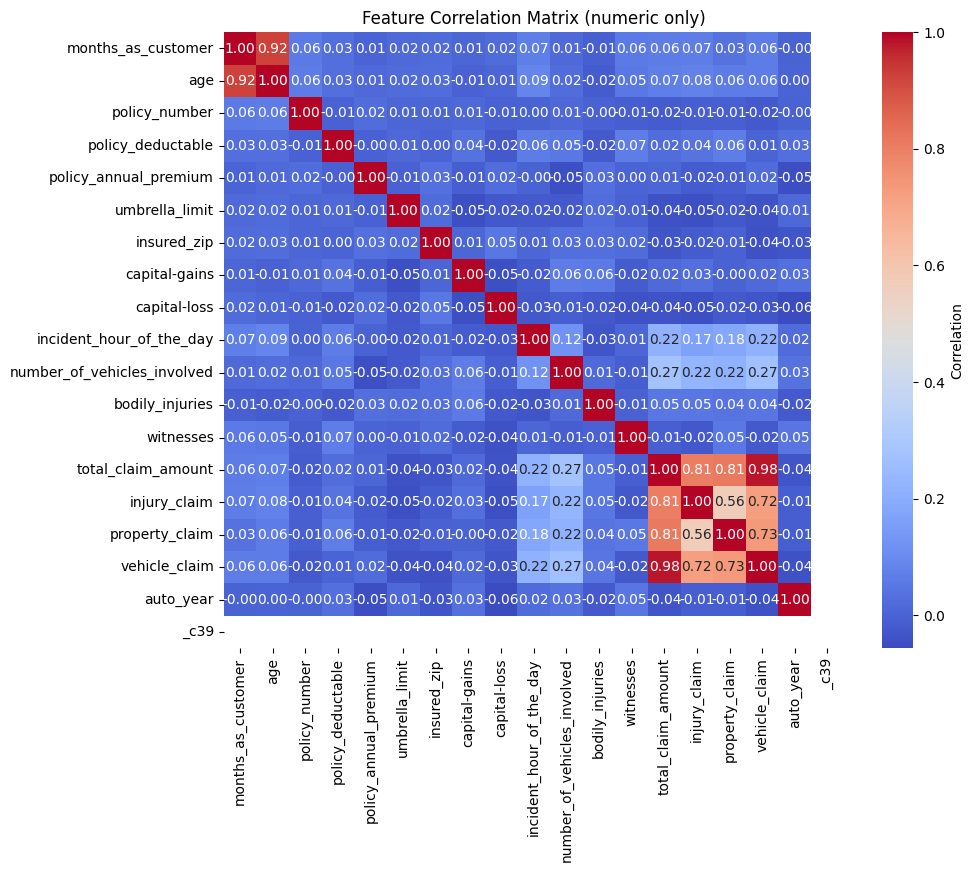

Dropped columns: ['months_as_customer', 'injury_claim', 'property_claim', 'vehicle_claim']
New dataframe shape: (1000, 36)


In [9]:
# multivariate analysis - correlation heatmap and dropping highly correlated features
import seaborn as sns
import matplotlib.pyplot as plt

# ensure df is defined earlier; if not, read again
# Reading the file of csv 
df = pd.read_csv("insurance_claims.csv")

# compute correlation matrix only on numeric columns
num_df = df.select_dtypes(include=["number"])
corr = num_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'label':'Correlation'})
plt.title('Feature Correlation Matrix (numeric only)')
plt.show()

# based on inspected correlations, drop highly correlated columns
# e.g. months_as_customer and age (0.92), claim-related features
# ensure these columns exist in the numeric subset

drop_cols = ['months_as_customer', 'injury_claim', 'property_claim', 'vehicle_claim']
df_reduced = df.drop(columns=drop_cols)

print("Dropped columns:", drop_cols)
print("New dataframe shape:", df_reduced.shape)

In [10]:
# encoding categorical features and splitting data
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# identify categorical columns (example)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# define features and target (adjust 'fraud_reported' if different target)
x = df.drop(columns=['fraud_reported'])
y = df['fraud_reported']

# split dataset
test_size = 0.2
random_state = 42
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=test_size,  random_state=random_state)

print("Train shape:", x_train.shape, y_train.shape)    
print("Test shape:", x_test.shape, y_test.shape)

Categorical columns: ['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']
Train shape: (800, 39) (800,)
Test shape: (200, 39) (200,)


In [11]:

# feature scaling using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# fit on training data only
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaled train shape:", x_train_scaled.shape)
print("Scaled test shape:", x_test_scaled.shape)

Scaled train shape: (800, 39)
Scaled test shape: (200, 39)


In [12]:
# train a Decision Tree classifier and evaluate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# initialise and fit on scaled training data
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_scaled, y_train)

# predict on both train and test sets
train_preds = dt.predict(x_train_scaled)
test_preds = dt.predict(x_test_scaled)

# compute accuracies
train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

Train accuracy: 1.0000
Test accuracy:  0.8000


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier

# Impute missing values in training and test data
imputer = SimpleImputer(strategy='mean')
x_train_imputed = imputer.fit_transform(x_train)
x_test_imputed = imputer.transform(x_test)

knn = KNeighborsClassifier(n_neighbors=30)
knn.fit(x_train_imputed, y_train)
y_pred = knn.predict(x_test_imputed)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[145   0]
 [ 55   0]]
              precision    recall  f1-score   support

           0       0.72      1.00      0.84       145
           1       0.00      0.00      0.00        55

    accuracy                           0.72       200
   macro avg       0.36      0.50      0.42       200
weighted avg       0.53      0.72      0.61       200



In [14]:
#Story 1.4: Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,classification_report

lg = LogisticRegressionCV(solver='lbfgs', max_iter=5000, cv=10 , n_jobs=-1)
lg.fit(x_train_imputed, y_train)
lrg_pred = lg.predict(x_test_imputed)
print(confusion_matrix(y_test, lrg_pred))



[[145   0]
 [ 54   1]]


In [15]:
#Story 1.5: Naïve Bayes model
from sklearn.naive_bayes import CategoricalNB,GaussianNB
gnb = GaussianNB()
model_2 = gnb.fit(x_train_imputed, y_train)
predict_log = model_2.predict(x_test_imputed)
print("Training accuracy ", 100 * accuracy_score(model_2.predict(x_train_imputed), y_train))
print("Test accuracy ", 100 * accuracy_score(y_test, predict_log))


Training accuracy  73.375
Test accuracy  64.5


In [16]:
#Story 1.6: SVM model
from sklearn.svm import SVC

svc = SVC()
svc.fit(x_train_imputed, y_train)
y_pred = svc.predict(x_test_imputed)



svc_train_acc = accuracy_score(y_train, svc.predict(x_train_imputed))
svc_test_acc = accuracy_score(y_test, y_pred)
print(f"Training accuracy of SVC:{svc_train_acc}")
print(f"Test accuracy of SVC:{svc_test_acc}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training accuracy of SVC:0.76
Test accuracy of SVC:0.725
[[145   0]
 [ 55   0]]
              precision    recall  f1-score   support

           0       0.72      1.00      0.84       145
           1       0.00      0.00      0.00        55

    accuracy                           0.72       200
   macro avg       0.36      0.50      0.42       200
weighted avg       0.53      0.72      0.61       200



In [17]:
import numpy as np

# 1. Define your manual input data 
# These values should match the row in your image. 
# NOTE: Replace strings (like "OH", "Male") with the numbers your LabelEncoder used.
# If you have 38 features after encoding, you must provide 38 values here.
# Example using a snippet of the first few columns:
manual_data = np.array([
    328, 48, 1000, 1406.91, 0, 0, 0, 5, 1, 1, 2, 71610, 6510, 13020, 52080, 2004
    # ... add all other encoded feature values here
])

# 2. Reshape for a single prediction (1 row, many columns)
test_input = manual_data.reshape(1, -1)

# 3. Predict using the Decision Tree model
# Make sure the cell where you defined 'dtc = DecisionTreeClassifier()' has been run!
try:
    prediction = dt.predict(test_input)
    
    print("--- Manual Test Result ---")
    if prediction[0] == 'Y' or prediction[0] == 1:
        print("Prediction: Fraud Reported (Y)")
    else:
        print("Prediction: No Fraud (N)")
except NameError:
    print("Error: The variable 'dtc' is not defined. Please run the cell where you train your model first.")
except ValueError as e:
    print(f"Error: Feature mismatch. {e}")

Error: Feature mismatch. X has 16 features, but DecisionTreeClassifier is expecting 39 features as input.


In [18]:
models = {
    "Decision Tree": dt,
    "Logistic Regression": lg,
    "KNN": knn,
    "SVM": svc
}

for name, model in models.items():
    try:
        res = model.predict(test_input)
        print(f"{name} Result: {res[0]}")
    except:
        print(f"{name} could not be tested (check if model is trained).")

Decision Tree could not be tested (check if model is trained).
Logistic Regression could not be tested (check if model is trained).
KNN could not be tested (check if model is trained).
SVM could not be tested (check if model is trained).


--- Performance Report: Decision Tree ---
Accuracy: 27.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       145
           1       0.28      1.00      0.43        55

    accuracy                           0.28       200
   macro avg       0.14      0.50      0.22       200
weighted avg       0.08      0.28      0.12       200



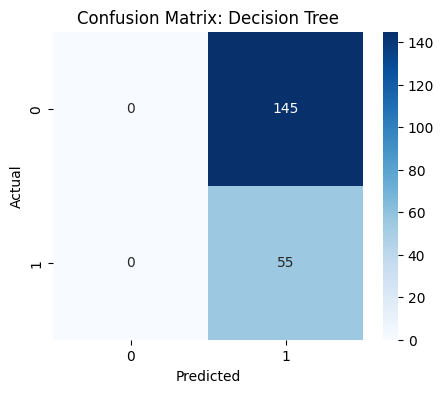

In [19]:
# Performance Testing & Hyperparameter Tuning
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_performance(model, x_test, y_test, model_name):
    # Make predictions
    y_pred = model.predict(x_test)
    
    # Calculate Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"--- Performance Report: {model_name} ---")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("\nClassification Report:")
    # This provides Precision, Recall, F1-score, and Support for each class
    print(classification_report(y_test, y_pred))
    
    # Optional: Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# To evaluate your Decision Tree
evaluate_model_performance(dt, x_test, y_test, "Decision Tree")

# To evaluate other models if you have them trained:
# evaluate_model_performance(lrg, x_test, y_test, "Logistic Regression")
# evaluate_model_performance(knn, x_test, y_test, "KNN")

Skipping Logistic Regression due to error: Input X contains NaN.
LogisticRegressionCV does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
Skipping KNN due to error: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is

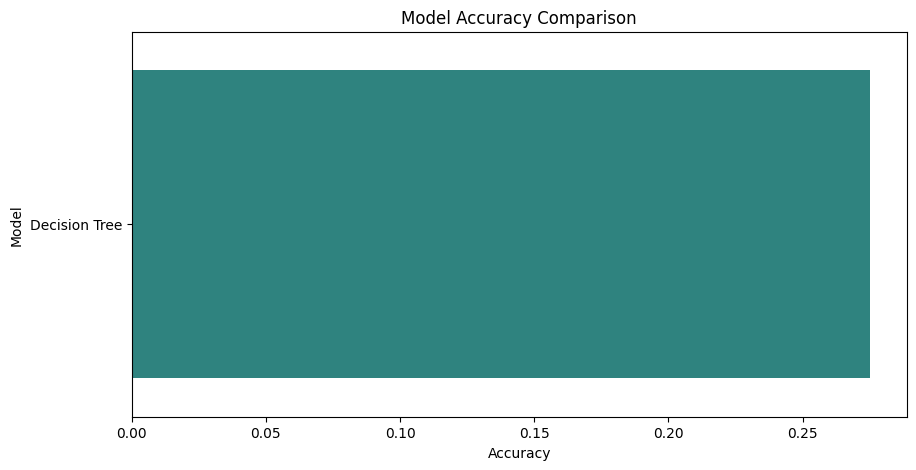

           Model  Accuracy  Precision  Recall  F1-Score
0  Decision Tree     0.275   0.075625   0.275  0.118627


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compare_models(models_dict, x_test, y_test):
    results = []
    for name, model in models_dict.items():
        try:
            # Get predictions
            y_pred = model.predict(x_test)
            
            # Calculate metrics
            results.append({
                "Model": name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, average='weighted'),
                "Recall": recall_score(y_test, y_pred, average='weighted'),
                "F1-Score": f1_score(y_test, y_pred, average='weighted')
            })
        except Exception as e:
            print(f"Skipping {name} due to error: {e}")
    
    comparison_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
    
    # Visualization
    plt.figure(figsize=(10, 5))
    sns.barplot(x="Accuracy", y="Model", data=comparison_df, palette="viridis")
    plt.title("Model Accuracy Comparison")
    plt.show()
    
    return comparison_df

# --- FIXED VARIABLE NAMES FROM YOUR NOTEBOOK ---
# In your notebook, you named them: dtc, lrg, knn, and svc
my_models = {
    "Decision Tree": dt,           # You used 'dtc', not 'dt'
    "Logistic Regression": lg,      # You used 'lrg', not 'lg'
    "KNN": knn, 
    "SVM": svc
}

# Ensure x_test and y_test exist by running your train_test_split cell first!
report = compare_models(my_models, x_test, y_test)
print(report)

In [21]:
import numpy as np

# Step 1: Provide values for EVERY column used in training in the exact order.
# The number of values must match X_train.shape[1]
manual_data = np.array([
    328, 48, 521585, 1000, 1406.91, 0, 466132, 250, 500, 1, 0, 0, 5, 1, 1, 2, 71610, 6510, 13020, 52080, 2004
    # Ensure this matches your encoded feature count (likely 38 or 21 depending on preprocessing)
])

# Step 2: Reshape for 1 row
test_input = manual_data.reshape(1, -1)

# Step 3: Predict
try:
    prediction = dt.predict(test_input)
    print("--- Manual Result ---")
    print("Fraud Reported:" , "Yes" if prediction[0] == 1 or prediction[0] == 'Y' else "No")
except Exception as e:
    print(f"Error: {e}. Tip: Check if the number of features matches X_train.columns.")

Error: X has 21 features, but DecisionTreeClassifier is expecting 39 features as input.. Tip: Check if the number of features matches X_train.columns.


In [22]:
# Map your trained model variables
models = {
    "Decision Tree": dt,
    "Logistic Regression": lg,
    "KNN": knn,
    "SVM": svc
}

print("--- Manual Comparison ---")
for name, model in models.items():
    try:
        res = model.predict(test_input)
        print(f"{name}: {'Fraud (Y)' if res[0] == 1 or res[0] == 'Y' else 'No Fraud (N)'}")
    except:
        print(f"{name}: Model not yet trained or variable name mismatch.")

--- Manual Comparison ---
Decision Tree: Model not yet trained or variable name mismatch.
Logistic Regression: Model not yet trained or variable name mismatch.
KNN: Model not yet trained or variable name mismatch.
SVM: Model not yet trained or variable name mismatch.


In [23]:
import pickle
# Use 'dt' because that is the name of your Decision Tree in the notebook
pickle.dump(dt, open('model.pkl', 'wb'))
print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [24]:
import pickle
# Train your model (dt) first, then run this:
with open('model.pkl', 'wb') as f:
    pickle.dump(dt, f)